 Visualization 2 - Seaborn -scatter/bar, distributions,categorical

Seaborn is built on top of matplotlib - its a wrapper that handles a lot of tedious setup (grouping, coloring by category, computing statistics) automatically. So you write less code ffor the same-often better looking result

In [1]:
import os
os.chdir("Data Sets")

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("all_athlete_games.csv",low_memory=False)

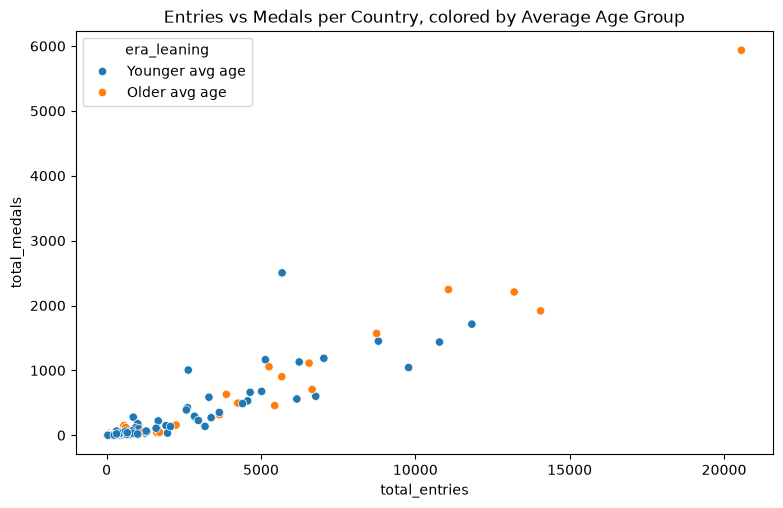

In [5]:
# Seaborn Wrapper

# sns.scatterplot, sns.barplot

# sns.scatterplot - like matplotlib's scatter but with easy category coloring

# sns.scatterplot(data=df,x=col,y=col,hue=category_col,ax=ax)

noc_summary = df.groupby("NOC").agg(
    total_entries=("Entry ID","count"),
    total_medals=("Medal", lambda x: x.notna().sum()),
    avg_age=("Age","mean")
).reset_index()
noc_summary = noc_summary[noc_summary["total_entries"] > 20]
noc_summary["era_leaning"] = noc_summary["avg_age"].apply(lambda a: "Older avg age" if a > 26 else "Younger avg age")

fig, ax = plt.subplots(figsize=(9,5.5))
sns.scatterplot(data=noc_summary, x="total_entries", y="total_medals", hue="era_leaning", ax=ax)
ax.set_title("Entries vs Medals per Country, colored by Average Age Group")
plt.show()

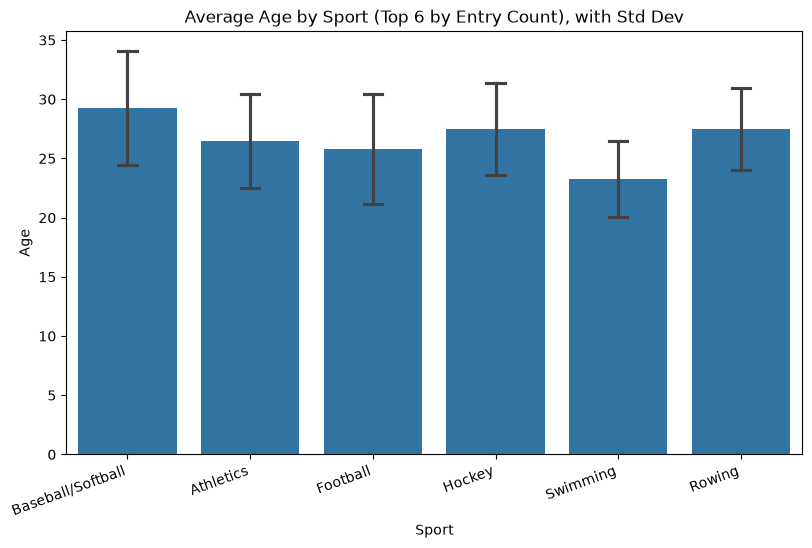

In [6]:
# sns.barplot

sample = df[(df["Year"]==2020) & (df["Medal"].notna())][["Name","Age","Sport"]].dropna(subset=["Age"])
top_sports = sample["Sport"].value_counts().head(6).index.tolist()
subset = sample[sample["Sport"].isin(top_sports)]

fig, ax = plt.subplots(figsize=(9.5,5.5))
sns.barplot(data=subset, x="Sport", y="Age", ax=ax, errorbar="sd", capsize=0.15)
ax.set_title("Average Age by Sport (Top 6 by Entry Count), with Std Dev")
plt.xticks(rotation=20, ha="right")
plt.show()